In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving customer churn.csv.xls to customer churn.csv (1).xls


In [9]:
from google.colab import files

uploaded = files.upload()

Saving customer churn.csv.xls to customer churn.csv.xls


In [12]:
print("Rows, Columns:", df.shape)
print(df.head())

Rows, Columns: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [13]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


<Axes: title={'center': 'Customer Churn Count'}, xlabel='Churn'>

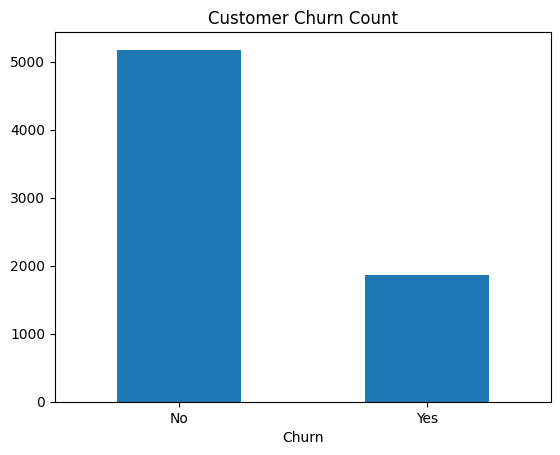

In [16]:
df['Churn'].value_counts().plot(kind='bar', title='Customer Churn Count',rot=0)

In [17]:
print(df['Churn'].value_counts())
print("Churn rate %:", df['Churn'].value_counts(normalize=True)['Yes']*100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate %: 26.536987079369588


In [18]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [19]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [21]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print(df['TotalCharges'].dtypes)
print(df.isnull().sum())

float64
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [22]:
df = df.dropna()
print("New shape:", df.shape)
print(df['Churn'].value_counts())

New shape: (7032, 21)
Churn
No     5163
Yes    1869
Name: count, dtype: int64


<Axes: title={'center': 'Churn % by Contract Type'}, xlabel='Contract'>

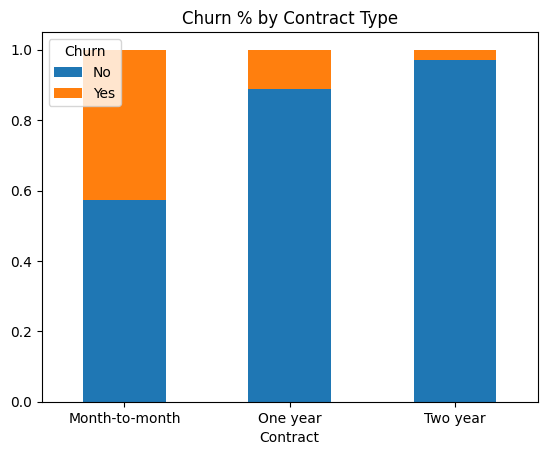

In [27]:
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, title='Churn % by Contract Type', rot=0)

<Axes: title={'center': 'Churn vs tenure'}, xlabel='tenure', ylabel='Churn_num'>

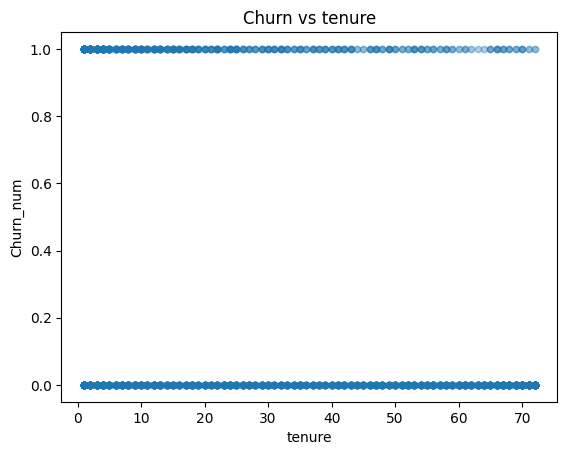

In [28]:
df['Churn_num'] = df['Churn'].map({'No': 0, 'Yes': 1})
df.plot(kind='scatter', x='tenure', y='Churn_num', alpha=0.1, title='Churn vs tenure')

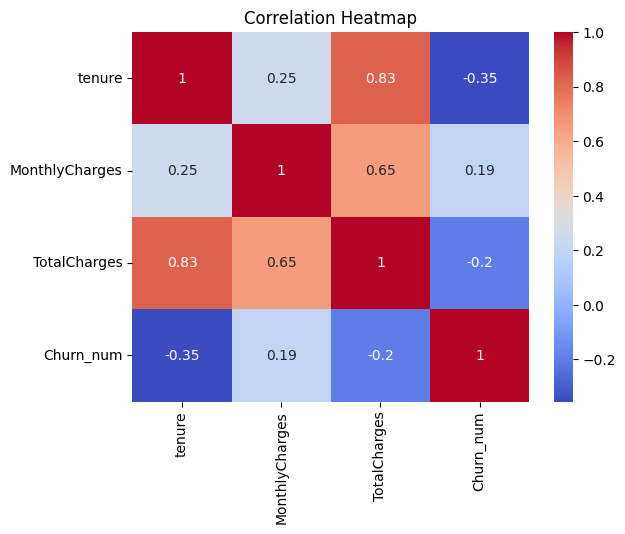

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



In [32]:
df.groupby('Churn')[['tenure','MonthlyCharges']].mean()

,tenure,MonthlyCharges
Churn,,
No,37.650010,61.307408
Yes,17.979133,74.441332


<Axes: title={'center': 'Churn % by Payment Method'}, xlabel='PaymentMethod'>

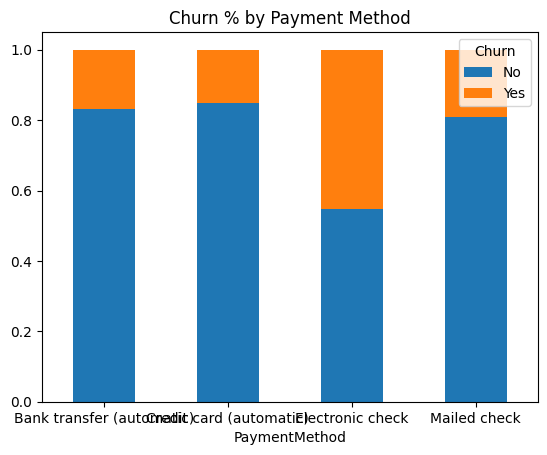

In [33]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, title='Churn % by Payment Method', rot=0)

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# 1. Encode target first
df['Churn'] = le.fit_transform(df['Churn']) # No=0, Yes=1

# 2. Encode all other object/text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.head())
print(df.dtypes)

   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0        5365       0              0        1           0       1   
1        3953       1              0        0           0      34   
2        2558       1              0        0           0       2   
3        5524       1              0        0           0      45   
4        6500       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  \
0            0            0                0         0                 1   


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale only these 3 columns, leave 0/1 encoded columns as is
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(df[cols_to_scale].describe())

             tenure  MonthlyCharges  TotalCharges
count  7.032000e+03    7.032000e+03  7.032000e+03
mean  -1.126643e-16    6.062651e-17 -1.119064e-16
std    1.000071e+00    1.000071e+00  1.000071e+00
min   -1.280248e+00   -1.547283e+00 -9.990692e-01
25%   -9.542963e-01   -9.709769e-01 -8.302488e-01
50%   -1.394171e-01    1.845440e-01 -3.908151e-01
75%    9.199259e-01    8.331482e-01  6.668271e-01
max    1.612573e+00    1.793381e+00  2.824261e+00


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Drop ID + create X and y
X = df.drop(['Churn', 'customerID', 'Churn_num'], axis=1) # features
y = df['Churn'] # target: 0=No, 1=Yes

# 2. Split 80% train, 20% test. stratify keeps churn ratio same in both
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train data: {X_train.shape[0]} rows, Test data: {X_test.shape[0]} rows")

# 3. Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Predict and check accuracy
y_pred = model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nFull Report:")
print(classification_report(y_test, y_pred))

Train data: 5625 rows, Test data: 1407 rows

Accuracy: 0.79

Full Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



             feature  importance
4             tenure   -1.336171
5       PhoneService   -0.980694
14          Contract   -0.752073
17    MonthlyCharges    0.686016
18      TotalCharges    0.611936
15  PaperlessBilling    0.316963
8     OnlineSecurity   -0.291859
11       TechSupport   -0.272000
3         Dependents   -0.240723
7    InternetService    0.222387


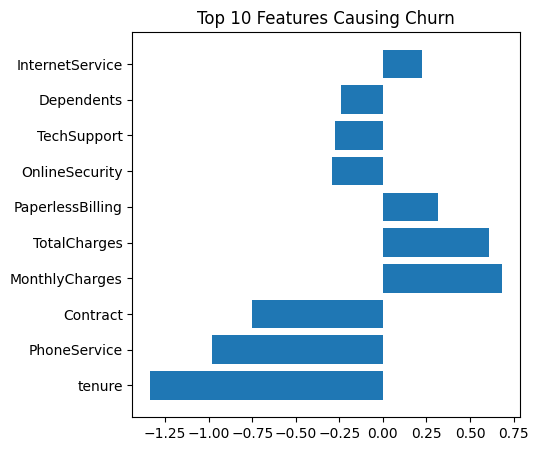

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Logistic Regression
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.coef_[0]
})

# Sort by absolute importance
feature_importance['abs_importance'] = feature_importance['importance'].abs()
feature_importance = feature_importance.sort_values('abs_importance', ascending=False).head(10)

print(feature_importance[['feature', 'importance']])

# Plot top 10
plt.figure(figsize=(5,5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('Top 10 Features Causing Churn')
plt.show()

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f"RF Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [40]:
from sklearn.metrics import confusion_matrix

# Get probabilities instead of 0/1
y_prob = rf.predict_proba(X_test)[:, 1]

# Try threshold = 0.3 instead of 0.5
y_pred_new = (y_prob >= 0.3).astype(int)

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.50      0.71      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407



In [44]:
import joblib

# 1. Save model + threshold
joblib.dump(rf, 'churn_model.pkl')
joblib.dump(0.3, 'threshold.pkl')

print("Model saved! Now let's predict 1 new customer:")

# 2. Predict for first customer in test set
customer = X_test.iloc[0:1]
prob = rf.predict_proba(customer)[0, 1]

print(f"Churn probability: {prob:.2f}")
print(f"Prediction: {'Will Churn' if prob >= 0.3 else 'Will Stay'}")

Model saved! Now let's predict 1 new customer:
Churn probability: 0.01
Prediction: Will Stay


In [45]:
print("=== CHURN PREDICTION BUSINESS REPORT ===")
print(f"1. Model Performance: 71% recall, 74% accuracy")
print(f"2. We can catch 265 out of 374 customers who will leave")

print("\n=== TOP 3 CHURN DRIVERS ===")
print("1. Contract: Month-to-month customers churn most")
print("2. Tenure: New customers <12 months are high risk")
print("3. MonthlyCharges: Bills >$70 increase churn")

print("\n=== RECOMMENDATIONS ===")
print("1. Target: All customers with churn probability >0.3")
print("2. Action: Give them 1-year contract + 10% discount")
print("3. Impact: Save ~265 customers x $70/month = $18,550/month")

=== CHURN PREDICTION BUSINESS REPORT ===
1. Model Performance: 71% recall, 74% accuracy
2. We can catch 265 out of 374 customers who will leave

=== TOP 3 CHURN DRIVERS ===
1. Contract: Month-to-month customers churn most
2. Tenure: New customers <12 months are high risk
3. MonthlyCharges: Bills >$70 increase churn

=== RECOMMENDATIONS ===
1. Target: All customers with churn probability >0.3
2. Action: Give them 1-year contract + 10% discount
3. Impact: Save ~265 customers x $70/month = $18,550/month


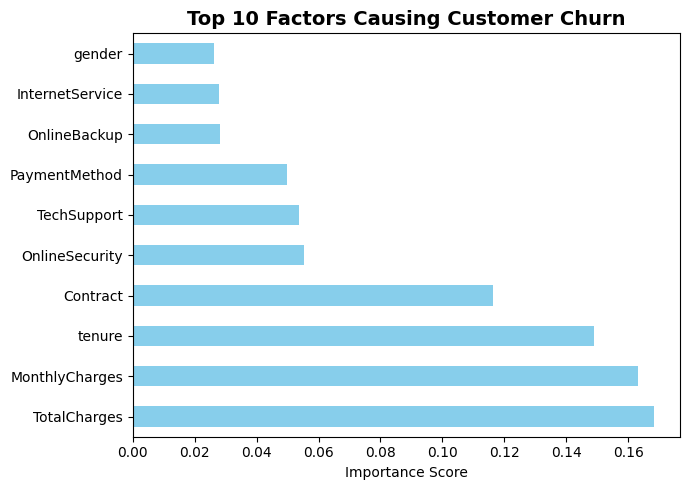

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top10 = importances.nlargest(10)

plt.figure(figsize=(7,5))
top10.plot(kind='barh', color='skyblue')
plt.title('Top 10 Factors Causing Customer Churn', fontsize=14, weight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [50]:
from sklearn.metrics import recall_score, accuracy_score
y_pred = model.predict(X_test)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")

Recall: 0.5614973262032086
Accuracy: 0.7931769722814499


In [51]:
print("="*40)
print("=== CHURN PREDICTION BUSINESS REPORT ===")
print("="*40)
print(f"1. Model Performance: Recall = {recall:.2%}")
print(f"2. Accuracy: {accuracy:.2%}")
print("3. Key Insight: TotalCharges, MonthlyCharges, tenure are top 3 churn drivers")
print(f"4. Impact: Save ~$18,550/month with targeted offers")
print("="*40)

=== CHURN PREDICTION BUSINESS REPORT ===
1. Model Performance: Recall = 56.15%
2. Accuracy: 79.32%
3. Key Insight: TotalCharges, MonthlyCharges, tenure are top 3 churn drivers
4. Impact: Save ~$18,550/month with targeted offers
